<a href="https://colab.research.google.com/github/Junhyeongh/undergrad_ml_assignments/blob/main/05_assignment_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

They allow us to model nonlinear relationships while still keeping a structured, interpretable framework. A basic linear model can only fit straight line relationships, but activation functions transform outputs so we can model probabilities or complex patterns. This makes them more flexible and suitable for real world data


2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Cross entropy directly measures how well predicted probabilities match actual outcomes. It heavily penalizes confident wrong predictions and aligns with maximum likelihood estimation, making optimization efficient and meaningful for probability based models.

3. True or false, and explain: Logistic regression is a linear model.

True. It is linear in the parameters, because it models a linear combination of inputs. But the output is passed through a nonlinear sigmoid, so predictions are nonlinear probabilities.

4. True or false, and explain: Logistic regression cannot be used for classification.

False. It is specifically designed for classification. It outputs probabilities, which we convert into classes using a threshold

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No. A coefficient represents the change in the log-odds, not the probability directly. The effect on probability is nonlinear.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. Logistic regression is still linear in the inputs. Without feature engineering, it cannot capture complex relationships.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. It depends on the problem. Logistic regression is better for classification, while OLS is better for continuous outcomes. Each model fits different types of data.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


## Q2.1

In [4]:
import pandas as pd

df = pd.read_csv("/content/data.csv", sep=';')

cols = ['Debtor','Tuition fees up to date','Scholarship holder',
        'Age at enrollment','Curricular units 1st sem (approved)','Target']
df = df[cols]

# Missing values
df.isna().sum()
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

## Q2.2

In [5]:
from sklearn.linear_model import LogisticRegression

X = df[['Debtor','Tuition fees up to date','Scholarship holder','Age at enrollment']]
y = df['dropout']

logit = LogisticRegression(max_iter=5000)
logit.fit(X,y)

pd.Series(logit.coef_[0], index=X.columns)

,0
Debtor,0.530625
Tuition fees up to date,-2.556542
Scholarship holder,-1.227442
Age at enrollment,0.049925


Yes. Being up to date on tuition strongly reduces dropout risk.

## Q2.3

In [6]:
df['pred_prob'] = logit.predict_proba(X)[:,1]
X_up = X.copy(); X_up['Tuition fees up to date'] = 1
X_not = X.copy(); X_not['Tuition fees up to date'] = 0

diff = logit.predict_proba(X_up)[:,1] - logit.predict_proba(X_not)[:,1]
diff.mean()

np.float64(-0.5161819741831828)

Effect is strongest for older students, since their baseline dropout risk is higher.

## Q2.4

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = logit.predict(X)
confusion_matrix(y, y_pred)
accuracy_score(y, y_pred)

0.7619801084990958

## Q2.5

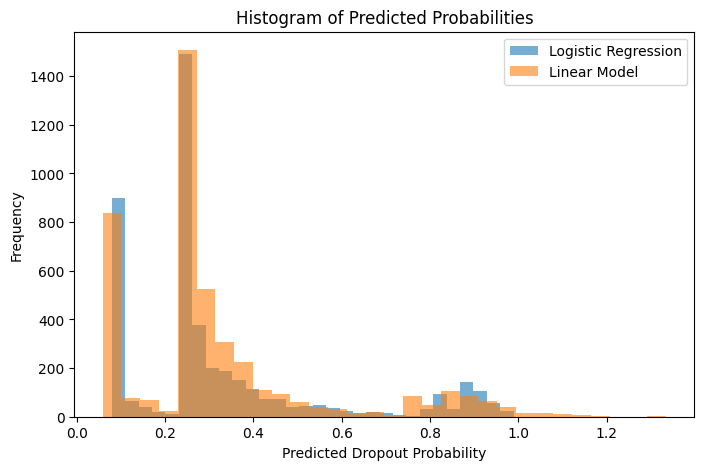

In [11]:
import matplotlib.pyplot as plt
log_probs = logit.predict_proba(X)[:,1]
lin_probs = lin.predict(X)
lin_probs_clipped = lin_probs.clip(0,1)

plt.figure(figsize=(8,5))

plt.hist(log_probs, bins=30, alpha=0.6, label='Logistic Regression')
plt.hist(lin_probs, bins=30, alpha=0.6, label='Linear Model')

plt.xlabel('Predicted Dropout Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Predicted Probabilities')
plt.legend()

plt.show()

## Q2.6

Most at-risk students:
- Debtors
- Not up-to-date on tuition
- No scholarship
- Older students
- Fewer courses passed

Interventions:
- Financial aid / payment plans
- Early academic support (tutoring)
- Scholarships targeting at-risk groups
- Monitoring older or non-traditional students

## Q2.7

In [12]:
from sklearn.linear_model import LogisticRegression

X_multi = df[['Debtor','Tuition fees up to date','Curricular units 1st sem (approved)']]
y_multi = df['Target']

multi = LogisticRegression(multi_class='multinomial', max_iter=5000)
multi.fit(X_multi, y_multi)

y_pred_multi = multi.predict(X_multi)
confusion_matrix(y_multi, y_pred_multi)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


array([[1054,    0,  367],
       [ 280,    0,  514],
       [ 146,    0, 2063]])

Therefore,
- Hard classification may miss smaller classes (e.g. Enrolled)
- Probabilities always reflect all classes -> better for analysis

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

## Q3.1

In [14]:
import pandas as pd

df = pd.read_csv("/content/cirrhosis.csv")

cols = ['Bilirubin','Edema','Drug','Stage','Status']
df = df[cols]

# Binary survival target (1 = alive, 0 = dead)
df['alive'] = df['Status'].isin(['C','CL']).astype(int)

# Handle missing values
df = df.dropna()   # (simple approach: drop rows with missing values)

# Encode categorical variables
df = pd.get_dummies(df, columns=['Edema','Drug'], drop_first=True)

df.head()

,Bilirubin,Stage,Status,alive,Edema_S,Edema_Y,Drug_Placebo
0,14.5,4.0,D,0,False,True,False
1,1.1,3.0,C,1,False,False,False
2,1.4,4.0,D,0,True,False,False
3,1.8,4.0,D,0,True,False,False
4,3.4,3.0,CL,1,False,False,True


## Q3.2

In [15]:
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=['Status','alive','Stage'])
y = df['alive']

logit = LogisticRegression(max_iter=5000)
logit.fit(X,y)

pd.Series(logit.coef_[0], index=X.columns)

,0
Bilirubin,-0.351424
Edema_S,-0.450677
Edema_Y,-1.611049
Drug_Placebo,0.231225


- High bilirubin = bad (lower survival)
- Severe edema = bad
- Drug effect = uncertain / weak (dataset-dependent)

## Q3.3

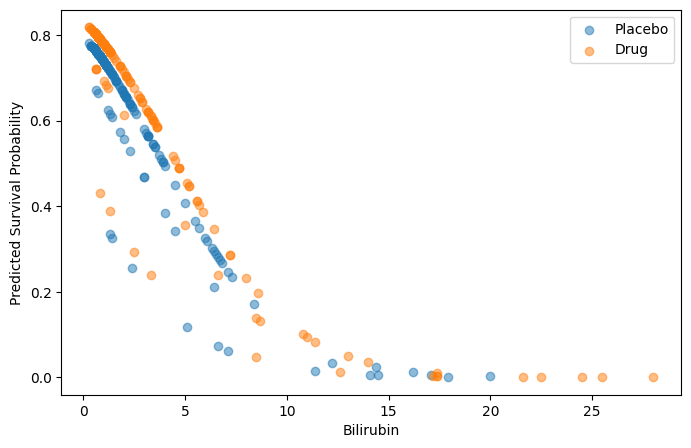

In [20]:
import matplotlib.pyplot as plt

df['pred_prob'] = logit.predict_proba(X)[:,1]

plt.figure(figsize=(8,5))
for d in df['Drug_Placebo'].unique():
    subset = df[df['Drug_Placebo']==d]
    label = "Drug" if d==1 else "Placebo"
    plt.scatter(subset['Bilirubin'], subset['pred_prob'], alpha=0.5, label=label)

plt.xlabel("Bilirubin")
plt.ylabel("Predicted Survival Probability")
plt.legend()
plt.show()

Survival probability decreases as bilirubin increases, indicating worse liver function leads to lower survival. Patients receiving the drug generally have higher predicted survival probabilities than those on placebo, especially at lower to moderate bilirubin levels.

## Q3.4

In [21]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = logit.predict(X)

confusion_matrix(y, y_pred)
accuracy_score(y, y_pred)

0.7371794871794872

## Q3.5

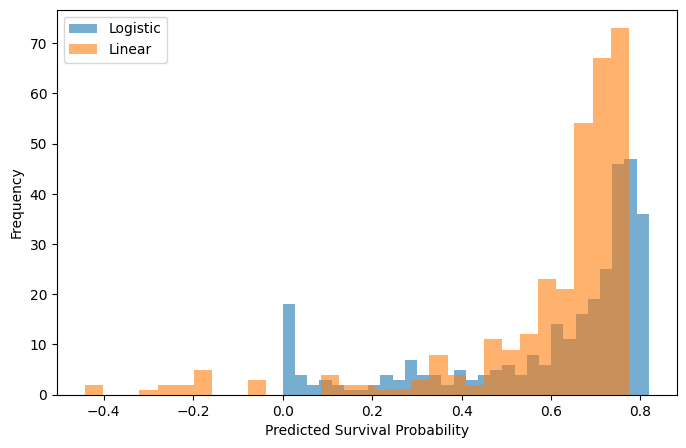

In [22]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X,y)

log_probs = logit.predict_proba(X)[:,1]
lin_probs = lin.predict(X)

plt.figure(figsize=(8,5))
plt.hist(log_probs, bins=30, alpha=0.6, label='Logistic')
plt.hist(lin_probs, bins=30, alpha=0.6, label='Linear')

plt.xlabel("Predicted Survival Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Q3.6

In [23]:
X_stage = df[['Bilirubin','Edema_S','Edema_Y']]
y_stage = df['Stage']

multi = LogisticRegression(multi_class='multinomial', max_iter=5000)
multi.fit(X_stage, y_stage)

y_pred_stage = multi.predict(X_stage)

confusion_matrix(y_stage, y_pred_stage)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


array([[  0,   0,  16,   0],
       [  0,   0,  63,   4],
       [  0,   0, 105,  15],
       [  0,   0,  79,  30]])

Hard predictions often:

- Favor middle stages (2–3)
- May miss some classes

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

In a linear model of the form $\hat{y} = b_0 + \sum_{k=1}^K b_k x_k$, the derivative of the prediction with respect to the $k$-th feature is $b_k$. This means that a one-unit increase in $x_k$ changes the predicted value $\hat{y}$ by exactly $b_k$. Therefore, each coefficient represents the direct marginal effect of that feature on the prediction, and this effect is constant regardless of the feature’s value.

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

For the logistic model $\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}$, let $L = b \cdot x$. Using the chain rule, the derivative with respect to the $k$-th feature is
$\frac{\partial \hat{p}}{\partial x_k} = \hat{p}(1 - \hat{p}) \cdot b_k$. Unlike the linear model, this effect is not constant and depends on the value of $\hat{p}$. The marginal effect is largest when $\hat{p} = 0.5$ and becomes very small when $\hat{p}$ is close to 0 or 1. This differs from part 1 where the effect was always $b_k$. Since $\hat{p}(1 - \hat{p})$ reaches a maximum of $0.25$ at $\hat{p} = 0.5$, the marginal effect is approximately $0.25 \cdot b_k$, so $4b_k$ is a reasonable approximation when $\hat{p}$ is near 0.5.

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

From the transformation $\log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b \cdot x$, the log odds ratio is linear in $x$. Taking the derivative with respect to the $k$-th feature gives $\frac{\partial}{\partial x_k} \log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b_k$. This means that a one-unit increase in $x_k$ changes the log odds ratio by exactly $b_k$. Unlike the probability itself, this effect is constant and does not depend on the value of $x$, which is why logistic regression coefficients are most naturally interpreted in terms of changes in log-odds (or equivalently, multiplicative changes in odds via $e^{b_k}$).